# How the lasso strike reduction works, visually

Companion to `light_strike_reduction.ipynb`. The aim is to show **what the `lasso()` optimizer does** at each stage, in pictures:

1. The problem: replace a book of options with a few options that have the same terminal payoff
2. Why an L1 penalty gives **exact zeros** (1D and 2D pictures)
3. The **α path**: how the fee level controls how many options survive
4. The **entry rule**: an option is kept only if its benefit beats its fee
5. **Reweighting**: why the iterations remove the shrinkage
6. The real 60-option book: grid search, refinement, iterations
7. What the **risk constraints** cost in fit
8. Final result

Sections 1 to 5 use a small 4-option toy book so every number can be checked by hand. Sections 6 to 8 run on the 60-option book from the original notebook.

### Imports and helpers (same as `light_strike_reduction.ipynb`)

In [1]:
import warnings

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda x: f"{x:_.0f}" if abs(x) >= 1_000 else f"{x:.4g}")


def bs(S, K, T, sigma, is_call):
    """Black-Scholes price and delta (r = 0)."""
    sd = sigma * np.sqrt(T)
    d1 = np.log(S / K) / sd + sd / 2
    call = S * norm.cdf(d1) - K * norm.cdf(d1 - sd)
    return np.where(is_call, call, call - S + K), norm.cdf(d1) - ~is_call


def unit_risk(K, is_call, S, T, sigma, shocks=(-0.05, -0.10)):
    """t0 risk of one unit of each option: gamma cash, theta (per day), vega (per vol point), delta hedged slides."""
    sd = sigma * np.sqrt(T)
    pdf = norm.pdf(np.log(S / K) / sd + sd / 2)
    price, delta = bs(S, K, T, sigma, is_call)
    risk = {"gamma_cash": pdf * S / sd / 100, "theta": -S * pdf * sigma / (2 * np.sqrt(T)) / 252, "vega": S * pdf * np.sqrt(T) / 100}
    for x in shocks:
        risk[f"slide_{x:+.0%}"] = bs(S * (1 + x), K, T, sigma, is_call)[0] - price - delta * S * x
    return pd.DataFrame(risk)


def _qr(X, y):
    """||y - X w||^2 = ||z - R w||^2 + const on scaled data, and the R2 of weights w."""
    s = np.sqrt(np.mean(y ** 2))
    q, R = np.linalg.qr(X.to_numpy() / s)
    ys = y.to_numpy() / s
    z = q.T @ ys
    sse_perp, sst = ys @ ys - z @ z, ((ys - ys.mean()) ** 2).sum()
    return R, z, lambda w: 1 - (((z - R @ w) ** 2).sum() + sse_perp) / sst


def _constraints(w, cols, risk, floors, bands):
    """reduced >= ratio * full for floors, |reduced - full| <= tol * |full| for bands (relative to |full|)."""
    full = risk.sum()
    rel = {m: risk.loc[cols, m].to_numpy() / abs(full[m]) @ w - np.sign(full[m]) for m in [*floors, *bands]}
    return ([rel[m] + (1 - k) * np.sign(full[m]) >= 0 for m, k in floors.items()]
            + [cp.abs(rel[m]) <= tol for m, tol in bands.items()])


def _solve(problem, w):
    """Solved weights with solver zeros cleaned, or None if infeasible."""
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            problem.solve(solver=cp.CLARABEL)
    except cp.SolverError:
        return None
    if problem.status not in ("optimal", "optimal_inaccurate"):
        return None
    w = np.maximum(w.value, 0.0)
    w[w < 1e-6 * w.max()] = 0.0
    return w

## 1. The problem

Each option `j` gets a **multiplier** `w_j ≥ 0` on its book quantity: `w_j = 1` keeps the position as it is and `w_j = 0` drops it. We look for `w` with **few non-zeros** such that

$$\text{reduced payoff}(S_T) = \sum_j w_j \, X_j(S_T) \;\approx\; y(S_T) = \sum_j X_j(S_T)$$

where `X_j(S_T)` is option j's terminal payoff (times its book quantity) in scenario `S_T`.

**Toy book:** 4 options with quantity 1, observed on 5 terminal spots, and at most 2 positions allowed.

,put_85,put_95,call_105,call_115,book
80,5,15,0,0,20
90,0,5,0,0,5
100,0,0,0,0,0
110,0,0,5,0,5
120,0,0,15,5,20


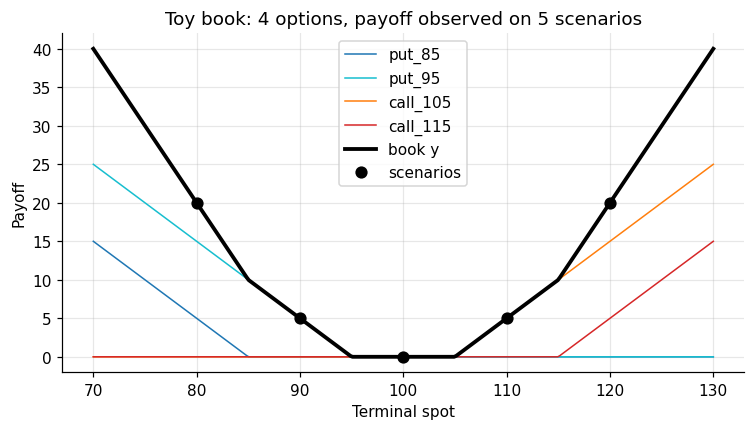

In [2]:
toy_S = np.array([80, 90, 100, 110, 120.0])
toy_K = np.array([85, 95, 105, 115.0])
toy_call = toy_K > 100
toy_names = ["put_85", "put_95", "call_105", "call_115"]
toy_X = pd.DataFrame(np.where(toy_call, np.maximum(toy_S[:, None] - toy_K, 0), np.maximum(toy_K - toy_S[:, None], 0)),
                     index=toy_S, columns=toy_names)
toy_y = toy_X.sum(axis=1)
display(toy_X.assign(book=toy_y))

colors = dict(zip(toy_names, ["tab:blue", "tab:cyan", "tab:orange", "tab:red"]))
s = np.linspace(70, 130, 300)
fig, ax = plt.subplots(figsize=(8, 4))
for k, c, n in zip(toy_K, toy_call, toy_names):
    ax.plot(s, np.maximum(s - k, 0) if c else np.maximum(k - s, 0), color=colors[n], lw=1, label=n)
book = sum(np.maximum(s - k, 0) if c else np.maximum(k - s, 0) for k, c in zip(toy_K, toy_call))
ax.plot(s, book, "k", lw=2.5, label="book y")
ax.plot(toy_S, toy_y, "ko", ms=7, label="scenarios")
ax.set(xlabel="Terminal spot", ylabel="Payoff", title="Toy book: 4 options, payoff observed on 5 scenarios")
ax.legend()
plt.show()

## 2. Why the L1 penalty gives exact zeros

The lasso objective in the code is

$$\min_{w \ge 0} \; \underbrace{\frac{1}{2n}\lVert y - Xw\rVert^2}_{\text{tracking error}} \; + \; \underbrace{\alpha \sum_j \text{pen}_j \, w_j}_{\text{fee per unit kept}}$$

### 2a. One option at a time

With a single option the tracking error is a parabola in `w` with its minimum at the least-squares weight `w*`. Adding the **straight-line** fee `α·w` tilts the parabola:

- while α is small the minimum just slides to the left,
- once α is larger than the **slope of the parabola at w = 0**, the minimum sits exactly at `w = 0` (the boundary of `w ≥ 0`) and stays there.

Compare with a **squared** fee `α·w²` (ridge). That fee is flat at 0, so it shrinks `w` but never makes it exactly 0.

slope of the tracking error at w=0: 65.0   least-squares weight w* = 1.30


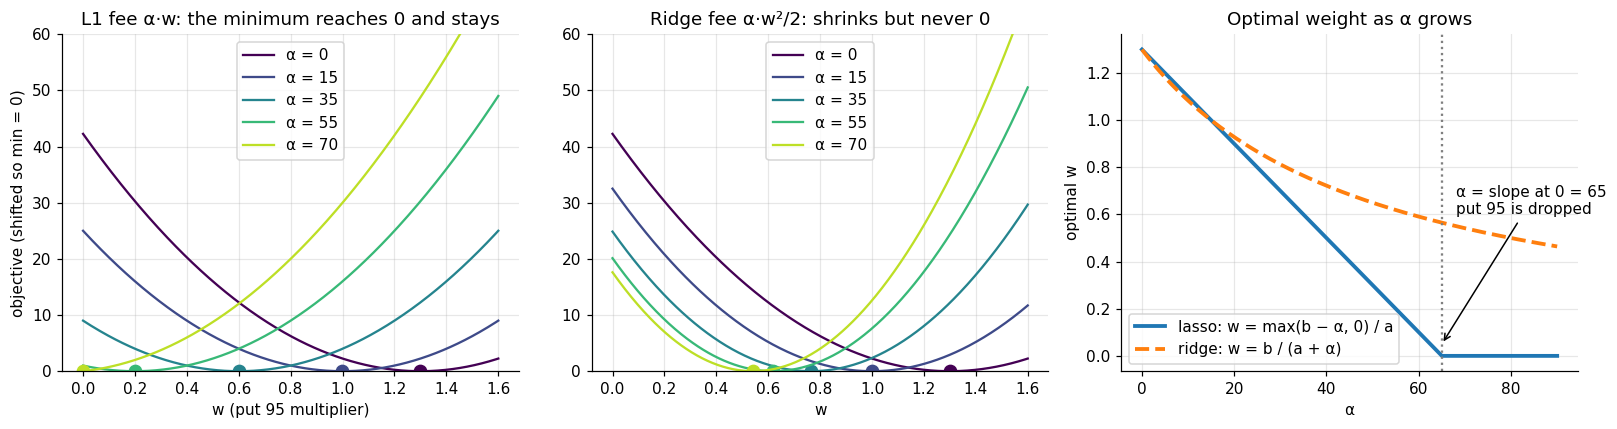

In [3]:
x = toy_X["put_95"].to_numpy()
y_put = np.array([20, 5, 0, 0, 0.0])  # the put side of the book
n = len(x)
a, b = x @ x / n, x @ y_put / n  # tracking error = a/2 w^2 - b w + const
w_star = b / a
print(f"slope of the tracking error at w=0: {b:.1f}   least-squares weight w* = {w_star:.2f}")

w_grid = np.linspace(0, 1.6, 400)
track = a / 2 * w_grid ** 2 - b * w_grid
alphas = [0, 15, 35, 55, 70]
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(alphas)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for al, c in zip(alphas, cmap):
    obj = track + al * w_grid
    axes[0].plot(w_grid, obj - obj.min(), color=c, label=f"α = {al}")
    axes[0].plot(w_grid[obj.argmin()], 0, "o", color=c, ms=8)
axes[0].set(xlabel="w (put 95 multiplier)", ylabel="objective (shifted so min = 0)", title="L1 fee α·w: the minimum reaches 0 and stays")
axes[0].set_ylim(0, 60)
axes[0].legend()

for al, c in zip([0, 15, 35, 55, 70], cmap):
    obj = track + al / 2 * w_grid ** 2
    axes[1].plot(w_grid, obj - obj.min(), color=c, label=f"α = {al}")
    axes[1].plot(w_grid[obj.argmin()], 0, "o", color=c, ms=8)
axes[1].set(xlabel="w", title="Ridge fee α·w²/2: shrinks but never 0")
axes[1].set_ylim(0, 60)
axes[1].legend()

al = np.linspace(0, 90, 300)
axes[2].plot(al, np.maximum(b - al, 0) / a, lw=2.5, label="lasso: w = max(b − α, 0) / a")
axes[2].plot(al, b / (a + al), lw=2.5, ls="--", label="ridge: w = b / (a + α)")
axes[2].axvline(b, color="grey", ls=":")
axes[2].annotate(f"α = slope at 0 = {b:.0f}\nput 95 is dropped", (b, 0.05), (b + 3, 0.6), arrowprops=dict(arrowstyle="->"))
axes[2].set(xlabel="α", ylabel="optimal w", title="Optimal weight as α grows")
axes[2].legend()
plt.tight_layout()
plt.show()

### 2b. Two options: the geometry

Take the two puts (85 and 95), which overlap because both pay at spot 80. The penalized problem is equivalent to a **budget** problem: minimize tracking error subject to `w85 + w95 ≤ t`.

- The **ellipses** are the levels of the tracking error, centred on the least-squares fit (★).
- The **budget** `w85 + w95 ≤ t` with `w ≥ 0` is a **triangle** with a corner on each axis.
- The solution is where the smallest ellipse touches the triangle. Because the triangle has **corners on the axes**, that contact point often sits on an axis, which means one weight is exactly 0.

A round (ridge) budget has no corners, so the contact point is almost never on an axis.

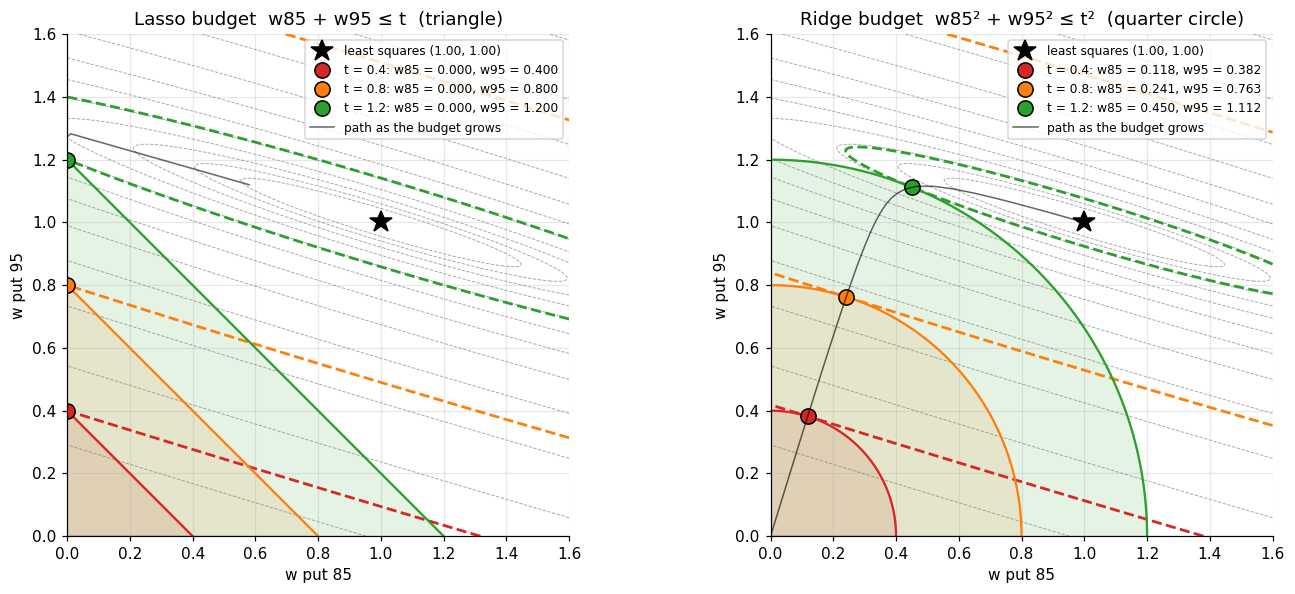

In [4]:
X2 = toy_X[["put_85", "put_95"]].to_numpy()
n = len(y_put)
G, g = X2.T @ X2 / n, X2.T @ y_put / n
w_ls = np.linalg.solve(G, g)


def tracking(W1, W2):
    W = np.stack([W1, W2], -1)
    return 0.5 * np.einsum("...i,ij,...j->...", W, G, W) - W @ g


def budget_fit(t, kind):
    w = cp.Variable(2, nonneg=True)
    cons = [cp.sum(w) <= t] if kind == "l1" else [cp.sum_squares(w) <= t ** 2]
    cp.Problem(cp.Minimize(0.5 * cp.quad_form(w, G) - g @ w), cons).solve()
    return np.maximum(w.value, 0)


W1, W2 = np.meshgrid(np.linspace(0, 1.6, 300), np.linspace(0, 1.6, 300))
Z = tracking(W1, W2)
budgets = [0.4, 0.8, 1.2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, kind, title in [(axes[0], "l1", "Lasso budget  w85 + w95 ≤ t  (triangle)"), (axes[1], "l2", "Ridge budget  w85² + w95² ≤ t²  (quarter circle)")]:
    ax.contour(W1, W2, Z, levels=tracking(*w_ls) + np.geomspace(0.05, 80, 14), colors="grey", linewidths=0.6, alpha=0.7)
    ax.plot(*w_ls, "k*", ms=15, label=f"least squares ({w_ls[0]:.2f}, {w_ls[1]:.2f})")
    for t, c in zip(budgets, ["tab:red", "tab:orange", "tab:green"]):
        if kind == "l1":
            ax.fill([0, t, 0], [0, 0, t], color=c, alpha=0.12)
            ax.plot([t, 0], [0, t], color=c)
        else:
            th = np.linspace(0, np.pi / 2, 100)
            ax.fill(np.r_[0, t * np.cos(th)], np.r_[0, t * np.sin(th)], color=c, alpha=0.12)
            ax.plot(t * np.cos(th), t * np.sin(th), color=c)
        sol = budget_fit(t, kind)
        Zs = tracking(*sol)
        ax.contour(W1, W2, Z, levels=[Zs], colors=[c], linewidths=1.8, linestyles="--")
        ax.plot(*sol, "o", color=c, ms=10, mec="k", label=f"t = {t}: w85 = {sol[0]:.3f}, w95 = {sol[1]:.3f}")
    # full lasso path in the plane
    path = np.array([budget_fit(t, kind) for t in np.linspace(0.01, 1.7, 80)])
    ax.plot(*path.T, "k-", lw=1, alpha=0.6, label="path as the budget grows")
    ax.set(xlabel="w put 85", ylabel="w put 95", title=title, xlim=(0, 1.6), ylim=(0, 1.6), aspect="equal")
    ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

**How to read it:** on the left (lasso) the first two budgets give **w85 = 0 exactly**. All the budget goes to put 95, which explains more of the payoff, and put 85 only enters once the budget is large. On the right (ridge) both weights are non-zero for every budget.

## 3. The α path: the fee level controls how many options survive

Back to the full toy book (4 options). We solve the lasso for many values of α, from high to low:

- **α ≥ `top`**: every weight is 0. `top = max_j (X_jᵀ y / n)` is the largest "benefit at zero" of any option. The code computes it as `top = (R.T @ z / n / strike_pen).max()`.
- As α decreases, options **enter one by one**, ordered by how much payoff they explain.
- At α → 0 we recover plain least squares on all options (`w = 1` reproduces the book exactly).

The code scans **30 values of α spaced on a log scale** from `top` to `top·1e-4` and keeps the best R² with ≤ `max_n` positions.

benefit at w = 0 (X_j' y / n): {'put_85': 20.0, 'put_95': 65.0, 'call_105': 65.0, 'call_115': 20.0}   ->  top = 65.0
best grid point with n <= 2: alpha = 0.762, R2 = 0.9854, weights = {'put_85': 0.0, 'put_95': 1.285, 'call_105': 1.285, 'call_115': 0.0}


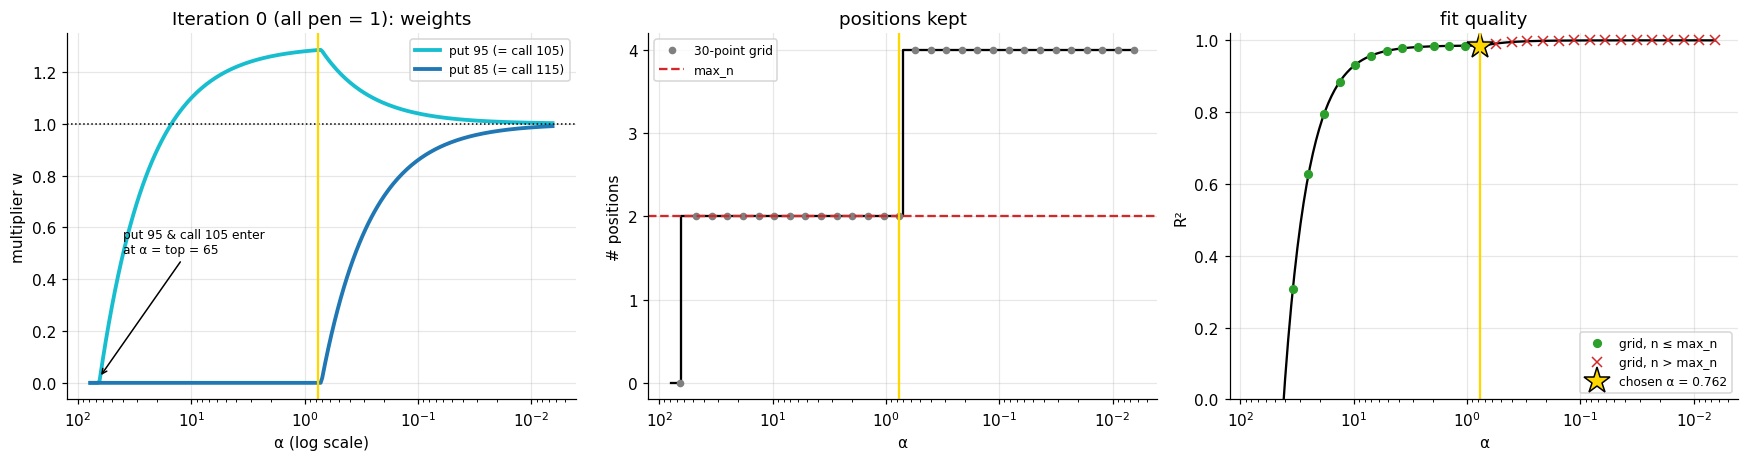

In [5]:
def toy_path(alphas, strike_pen, X=toy_X, y=toy_y):
    Xn, yn = X.to_numpy(), y.to_numpy()
    n, p = Xn.shape
    w, pen = cp.Variable(p, nonneg=True), cp.Parameter(p, nonneg=True)
    prob = cp.Problem(cp.Minimize(cp.sum_squares(Xn @ w - yn) / (2 * n) + pen @ w))
    rows = []
    for al in alphas:
        pen.value = al * strike_pen
        c = _solve(prob, w)
        c[c < 1e-4] = 0  # toy problem: clean solver noise on an absolute scale
        r2 = 1 - ((yn - Xn @ c) ** 2).sum() / ((yn - yn.mean()) ** 2).sum()
        rows.append({"alpha": al, "n": int((c > 0).sum()), "r2": r2, **dict(zip(X.columns, c))})
    return pd.DataFrame(rows)


n_toy, max_n_toy = len(toy_y), 2
benefit0 = toy_X.T @ toy_y / n_toy
top = benefit0.max()
print("benefit at w = 0 (X_j' y / n):", benefit0.to_dict(), "  ->  top =", top)

grid = np.geomspace(top, top * 1e-4, 30)
path0 = toy_path(np.geomspace(top * 1.2, top * 1e-4, 300), np.ones(4))
grid0 = toy_path(grid, np.ones(4))
ok = grid0[grid0["n"] <= max_n_toy]
best0 = ok.loc[ok["r2"].idxmax()]
print(f"best grid point with n <= {max_n_toy}: alpha = {best0.alpha:.3f}, R2 = {best0.r2:.4f}, weights =",
      best0[toy_names].round(3).to_dict())


def plot_path(path, grid_pts, best, title, axes):
    for nme, lbl in [("put_95", "put 95 (= call 105)"), ("put_85", "put 85 (= call 115)")]:
        axes[0].plot(path["alpha"], path[nme], color=colors[nme], lw=2.5, label=lbl)
    axes[0].axhline(1, color="k", ls=":", lw=1)
    axes[0].set(xscale="log", xlabel="α (log scale)", ylabel="multiplier w", title=f"{title}: weights")
    axes[0].invert_xaxis()
    axes[1].step(path["alpha"], path["n"], where="post", color="k")
    axes[1].plot(grid_pts["alpha"], grid_pts["n"], "o", color="grey", ms=4, label="30-point grid")
    axes[1].axhline(max_n_toy, color="tab:red", ls="--", label="max_n")
    axes[1].set(xscale="log", xlabel="α", ylabel="# positions", title="positions kept", yticks=range(5))
    axes[1].invert_xaxis()
    axes[2].plot(path["alpha"], path["r2"], color="k")
    feasible = grid_pts["n"] <= max_n_toy
    axes[2].plot(grid_pts.loc[feasible, "alpha"], grid_pts.loc[feasible, "r2"], "o", color="tab:green", ms=5, label="grid, n ≤ max_n")
    axes[2].plot(grid_pts.loc[~feasible, "alpha"], grid_pts.loc[~feasible, "r2"], "x", color="tab:red", ms=6, label="grid, n > max_n")
    axes[2].plot(best["alpha"], best["r2"], "*", color="gold", mec="k", ms=18, label=f"chosen α = {best['alpha']:.3f}")
    axes[2].set(xscale="log", xlabel="α", ylabel="R²", title="fit quality", ylim=(0, 1.02))
    axes[2].invert_xaxis()
    for ax in axes:
        ax.axvline(best["alpha"], color="gold", lw=1.5)
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    axes[2].legend(fontsize=8, loc="lower right")


fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
plot_path(path0, grid0, best0, "Iteration 0 (all pen = 1)", axes)
axes[0].annotate("put 95 & call 105 enter\nat α = top = 65", (65, 0.02), (40, 0.5), arrowprops=dict(arrowstyle="->"), fontsize=8)
plt.tight_layout()
plt.show()

Puts and calls are mirror images in this toy, so put 95 and call 105 follow the same curve, as do put 85 and call 115. Only the puts are drawn.

Read the plots from left to right (high α to low α). Put 95 and call 105 enter at α = 65 and grow, and the wings enter much later, around α ≈ 0.71. The chosen α (gold) is the **last grid point before a third position appears**: it has the most freedom still allowed by `max_n`.

**Refinement step:** the true entry point of the wings lies between the chosen grid point and the next one. The code scans 15 more values of α in that gap (`n_refine`) to get as close to the entry point as possible without crossing it.

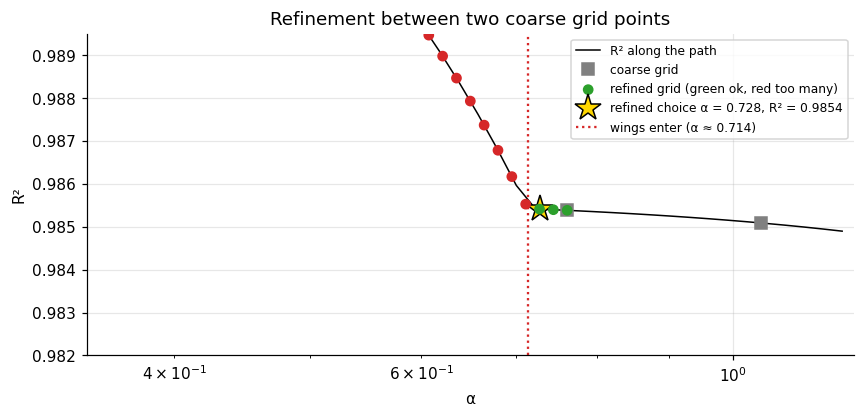

In [6]:
smaller = grid[grid < best0.alpha][0]
refined = toy_path(np.geomspace(best0.alpha, smaller, 15), np.ones(4))
ok_r = refined[refined["n"] <= max_n_toy]
best0r = ok_r.loc[ok_r["r2"].idxmax()] if ok_r["r2"].max() > best0.r2 else best0

fig, ax = plt.subplots(figsize=(9, 3.8))
zoom = path0[(path0.alpha <= best0.alpha * 1.6) & (path0.alpha >= smaller / 1.6)]
ax.plot(zoom["alpha"], zoom["r2"], "k", lw=1, label="R² along the path")
ax.plot(grid0["alpha"], grid0["r2"], "s", color="grey", ms=8, label="coarse grid")
ax.scatter(refined["alpha"], refined["r2"], c=np.where(refined["n"] <= max_n_toy, "tab:green", "tab:red"), zorder=3, label="refined grid (green ok, red too many)")
ax.plot(best0r["alpha"], best0r["r2"], "*", color="gold", mec="k", ms=18, label=f"refined choice α = {best0r['alpha']:.3f}, R² = {best0r['r2']:.4f}")
ax.axvline(0.714, color="tab:red", ls=":", label="wings enter (α ≈ 0.714)")
ax.set(xscale="log", xlabel="α", ylabel="R²", xlim=(best0.alpha * 1.6, smaller / 1.6), ylim=(0.982, 0.9895), title="Refinement between two coarse grid points")
ax.invert_xaxis()
ax.legend(fontsize=8)
plt.show()

## 4. The entry rule: benefit vs fee

At the optimum each option satisfies a simple condition (the KKT conditions):

- **benefit_j** = `X_jᵀ(y − Xw) / n`, the correlation of the option with the **payoff still unexplained**.
- If `w_j > 0`: benefit_j = α·pen_j **exactly** (the marginal gain equals the marginal fee).
- If `w_j = 0`: benefit_j ≤ α·pen_j (adding a little of the option costs more than it gains).

So an option is in the book **only if its benefit reaches its fee**. The chart below shows this at three values of α.

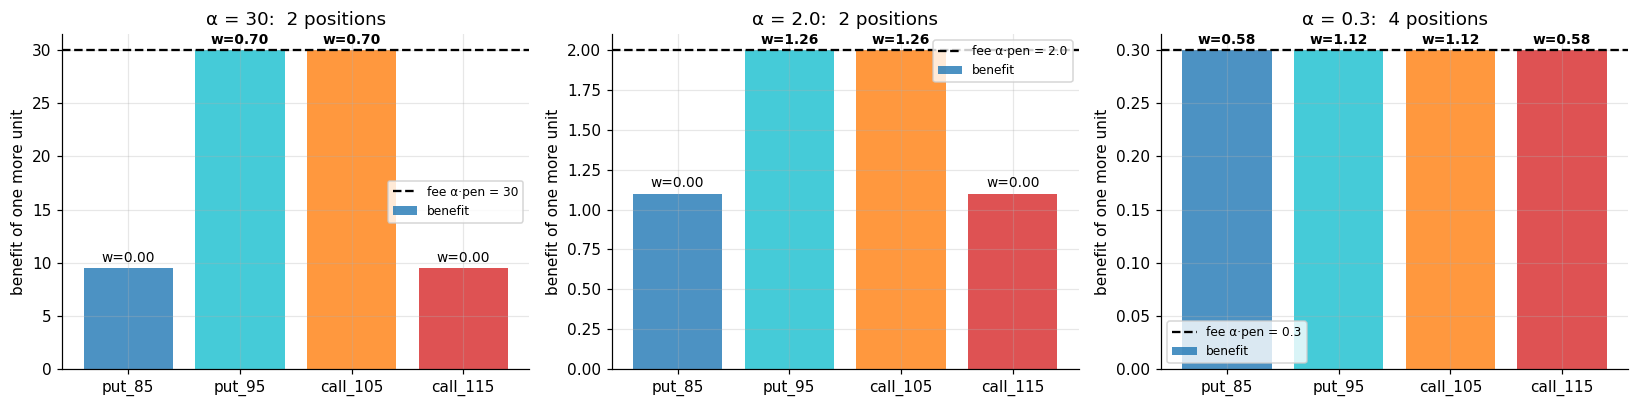

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, al in zip(axes, [30, 2.0, 0.3]):
    row = toy_path([al], np.ones(4)).iloc[0]
    w = row[toy_names].to_numpy(float)
    benefit = toy_X.T.to_numpy() @ (toy_y.to_numpy() - toy_X.to_numpy() @ w) / n_toy
    xs = np.arange(4)
    ax.bar(xs, benefit, color=[colors[c] for c in toy_names], alpha=0.8, label="benefit")
    ax.axhline(al, color="k", ls="--", label=f"fee α·pen = {al}")
    for i, (bb, ww) in enumerate(zip(benefit, w)):
        ax.text(i, bb + 0.02 * max(benefit.max(), al), f"w={ww:.2f}", ha="center", fontsize=9, fontweight="bold" if ww > 0 else "normal")
    ax.set_xticks(xs, toy_names)
    ax.set(title=f"α = {al}:  {int((w > 0).sum())} positions", ylabel="benefit of one more unit")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Bars that **touch the dashed line** are kept (benefit = fee). Bars **below** it are dropped. As α falls, the line comes down and the wing bars reach it.

## 5. Reweighting: removing the shrinkage

A flat fee has a side effect: to stay at 2 positions the code needs α ≈ 0.76, and that fee also pushes the **kept** options below their best size (1.285 instead of 1.30).

The fix (`strike_pen = 1 / (w + eps_scale · mean(w > 0))`) changes each option's fee after every solve:

| after a solve | new fee multiplier |
|---|---|
| option is large | small (it is cheap to keep it) |
| option is 0 | large: `1 / (0.5·mean)` (it is hard to bring it in) |

Kept options are shrunk less, and options that were dropped need a lower α before they come back. This approximates "count the positions" (an L0 penalty) while each solve stays a convex problem.

,alpha,r2,pen put_85,pen put_95,pen call_105,pen call_115,w put_85,w put_95,w call_105,w call_115
iteration,,,,,,,,,,
0,0.7281,0.9854,1,1,1,1,0,1.285,1.285,0
1,0.3599,0.9857,1.556,0.5186,0.5186,1.556,0,1.296,1.296,0
2,0.3629,0.9857,1.543,0.5143,0.5143,1.543,0,1.296,1.296,0
3,0.3629,0.9857,1.543,0.5143,0.5143,1.543,0,1.296,1.296,0


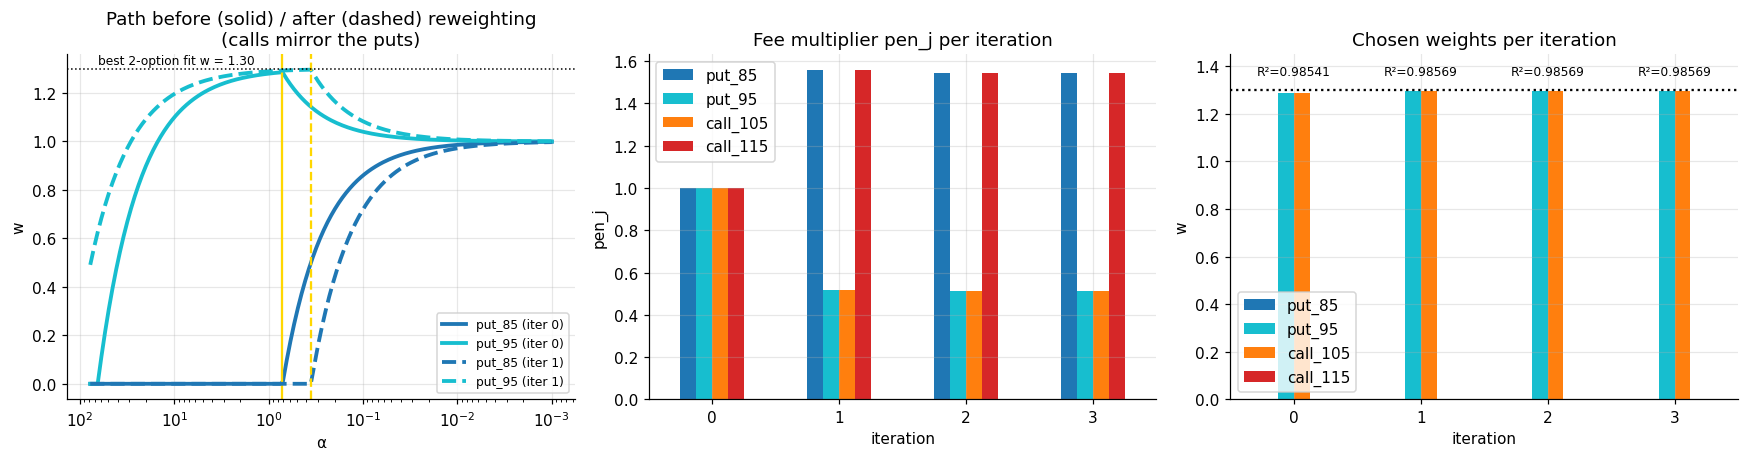

In [8]:
eps_scale = 0.5
strike_pen, history = np.ones(4), []
for it in range(4):
    grid_i = toy_path(np.geomspace((benefit0 / strike_pen).max(), (benefit0 / strike_pen).max() * 1e-4, 30), strike_pen)
    sm = grid_i[grid_i.n <= max_n_toy]
    b = sm.loc[sm.r2.idxmax()]
    # refine like the code
    nxt = grid_i.alpha[grid_i.alpha < b.alpha]
    if len(nxt):
        ref = toy_path(np.geomspace(b.alpha, nxt.iloc[0], 15), strike_pen)
        ref = ref[ref.n <= max_n_toy]
        if len(ref) and ref.r2.max() > b.r2:
            b = ref.loc[ref.r2.idxmax()]
    wv = b[toy_names].to_numpy(float)
    history.append({"iteration": it, "alpha": b.alpha, "r2": b.r2, **{f"pen {k}": v for k, v in zip(toy_names, strike_pen)},
                    **{f"w {k}": v for k, v in zip(toy_names, wv)}, "path": toy_path(np.geomspace(top * 1.2, 1e-3, 250), strike_pen)})
    strike_pen = 1 / (wv + eps_scale * wv[wv > 0].mean())

hist = pd.DataFrame(history).set_index("iteration")
display(hist.drop(columns="path"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for it, ls in [(0, "-"), (1, "--")]:
    p = hist.loc[it, "path"]
    for nme in ("put_85", "put_95"):
        axes[0].plot(p["alpha"], p[nme], color=colors[nme], ls=ls, lw=2.5, label=f"{nme} (iter {it})")
    axes[0].axvline(hist.loc[it, "alpha"], color="gold", ls=ls)
axes[0].axhline(1.3, color="k", ls=":", lw=1)
axes[0].text(top, 1.32, "best 2-option fit w = 1.30", fontsize=8)
axes[0].set(xscale="log", xlabel="α", ylabel="w", title="Path before (solid) / after (dashed) reweighting\n(calls mirror the puts)")
axes[0].invert_xaxis()
axes[0].legend(fontsize=8)

pens = hist[[f"pen {k}" for k in toy_names]]
pens.columns = toy_names
pens.plot.bar(ax=axes[1], color=[colors[c] for c in toy_names], rot=0)
axes[1].set(title="Fee multiplier pen_j per iteration", ylabel="pen_j")

ws = hist[[f"w {k}" for k in toy_names]]
ws.columns = toy_names
ws.plot.bar(ax=axes[2], color=[colors[c] for c in toy_names], rot=0)
axes[2].axhline(1.3, color="k", ls=":")
axes[2].set(title="Chosen weights per iteration", ylabel="w", ylim=(0, 1.45))
for it in hist.index:
    axes[2].text(it, 1.36, f"R²={hist.loc[it, 'r2']:.5f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

After one reweighting step the wings carry a **3× larger fee** (1.56 vs 0.52), so they enter only at a much lower α (the dashed curves move left). The kept options then grow to ≈ 1.296, almost the best possible 1.30. Iterating further changes nothing, so the procedure has converged.

## 6. The real book: 60 options, max 8 positions

Same setup as `light_strike_reduction.ipynb`. Below, `lasso_traced` is **the same algorithm** as `lasso()` with every fit recorded so we can plot it.

Before solving, the code compresses the problem with `_qr`: the 5,000 scenarios × 60 options become a 60 × 60 problem `‖z − Rw‖²` with the same answer.

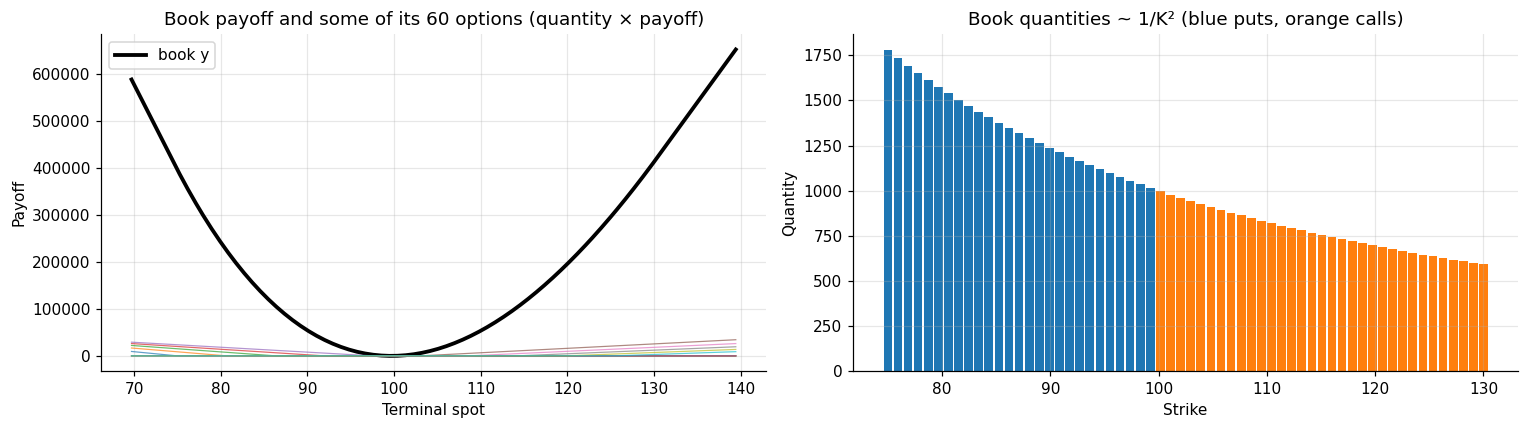

In [9]:
S0, T, sigma = 100.0, 60 / 252, 0.20
strikes = np.linspace(75, 130, 60)
is_call = strikes >= S0
names = [f"{'call' if c else 'put'}_{k:.1f}" for k, c in zip(strikes, is_call)]
portfolio_weight = pd.Series(1e7 / strikes ** 2, index=names)

rng = np.random.default_rng(42)
spots = S0 * np.exp(sigma * np.sqrt(T) * rng.standard_normal(5_000) - sigma ** 2 * T / 2)
option_terminal_payoff = pd.DataFrame(np.where(is_call, np.maximum(spots[:, None] - strikes, 0), np.maximum(strikes - spots[:, None], 0)),
                                      index=spots, columns=names)
risk_t0 = unit_risk(strikes, is_call, S0, T, sigma).set_axis(names)
option_bid_offer = pd.Series(-0.01 * (strikes - S0) ** 2, index=names)

risk_floor, risk_tolerance, max_n, pnl_haircut = ["gamma_cash", "theta", "slide_-5%", "slide_-10%"], {"vega": 0.05}, 8, 0.8
floors = dict.fromkeys(risk_floor, 1.0) | {"bid_offer": pnl_haircut}
risk_all = risk_t0.assign(bid_offer=option_bid_offer)

X = option_terminal_payoff[names] * portfolio_weight
y = X.sum(axis=1)
risk = risk_all.loc[names].mul(portfolio_weight, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
grid_s = np.sort(spots)
axes[0].plot(grid_s, y.loc[grid_s], "k", lw=2.5, label="book y")
for j in range(0, 60, 6):
    axes[0].plot(grid_s, X.loc[grid_s].iloc[:, j], lw=0.8, alpha=0.7)
axes[0].set(xlabel="Terminal spot", ylabel="Payoff", title="Book payoff and some of its 60 options (quantity × payoff)")
axes[0].legend()
axes[1].bar(strikes, portfolio_weight, width=0.8, color=np.where(is_call, "tab:orange", "tab:blue"))
axes[1].set(xlabel="Strike", ylabel="Quantity", title="Book quantities ~ 1/K² (blue puts, orange calls)")
plt.tight_layout()
plt.show()

In [10]:
def lasso_traced(X, y, risk, max_n, floors, bands, eps_scale=0.5, n_iter=10, n_grid=30, n_refine=15, constrained=True):
    """Same algorithm as lasso() in light_strike_reduction.ipynb, but records every fit."""
    n, p = X.shape
    R, z, r2 = _qr(X, y)
    w, pen = cp.Variable(p, nonneg=True), cp.Parameter(p, nonneg=True)
    cons = _constraints(w, X.columns, risk, floors, bands) if constrained else []
    problem = cp.Problem(cp.Minimize(cp.sum_squares(R @ w - z) / (2 * n) + pen @ w), cons)
    trace = []

    def fit(alpha, strike_pen, it, stage):
        pen.value = alpha * strike_pen
        c = _solve(problem, w)
        f = None if c is None else {"alpha": alpha, "n": int((c > 0).sum()), "r2": r2(c), "w": c}
        trace.append({"iter": it, "stage": stage, "alpha": alpha, "feasible": f is not None,
                      "n": np.nan if f is None else f["n"], "r2": np.nan if f is None else f["r2"]})
        return f

    def best_alpha(strike_pen, it):
        top = (R.T @ z / n / strike_pen).max()
        grid = [f for a in np.geomspace(top, top * 1e-4, n_grid) if (f := fit(a, strike_pen, it, "grid"))]
        best = max([f for f in grid if f["n"] <= max_n] or [min(grid, key=lambda f: f["n"])], key=lambda f: f["r2"])
        if smaller := [f["alpha"] for f in grid if f["alpha"] < best["alpha"]]:
            refined = [f for a in np.geomspace(best["alpha"], smaller[0], n_refine) if (f := fit(a, strike_pen, it, "refine"))]
            best = max([best, *[f for f in refined if f["n"] <= max_n]], key=lambda f: f["r2"])
        return best, top

    strike_pen, best, iters = np.ones(p), None, []
    for it in range(n_iter):
        f, top = best_alpha(strike_pen, it)
        iters.append({"iter": it, "top": top, "alpha": f["alpha"], "n": f["n"], "r2": f["r2"], "w": f["w"], "pen": strike_pen.copy()})
        if f["n"] <= max_n and (best is None or f["r2"] > best["r2"]):
            best = f
        strike_pen = 1 / (f["w"] + eps_scale * f["w"][f["w"] > 0].mean())
    return best, pd.DataFrame(trace), pd.DataFrame(iters)


best, trace, iters = lasso_traced(X, y, risk, max_n, floors, risk_tolerance)
print(f"best: alpha = {best['alpha']:.3g}, positions = {best['n']}, R2 = {best['r2']:.4%}")
display(iters[["iter", "top", "alpha", "n", "r2"]])

best: alpha = 0.000285, positions = 8, R2 = 99.8065%


,iter,top,alpha,n,r2
0,0,0.0532,0.004192,8,0.9495
1,1,0.431,0.001183,8,0.9848
2,2,0.519,0.000357,8,0.9962
3,3,0.4016,0.0002466,8,0.9974
4,4,0.3953,0.0002658,8,0.998
5,5,0.4134,0.0002779,8,0.9981
6,6,0.4214,0.0002833,8,0.9981
7,7,0.4235,0.0002847,8,0.9981
8,8,0.424,0.0002851,8,0.9981
9,9,0.4241,0.0002851,8,0.9981


### 6a. Grid search inside one iteration

Every dot is one convex solve. Green dots satisfy `n ≤ 8`, red dots have too many positions, and grey crosses are infeasible (the risk constraints cannot be met). The gold star is the α kept for that iteration.

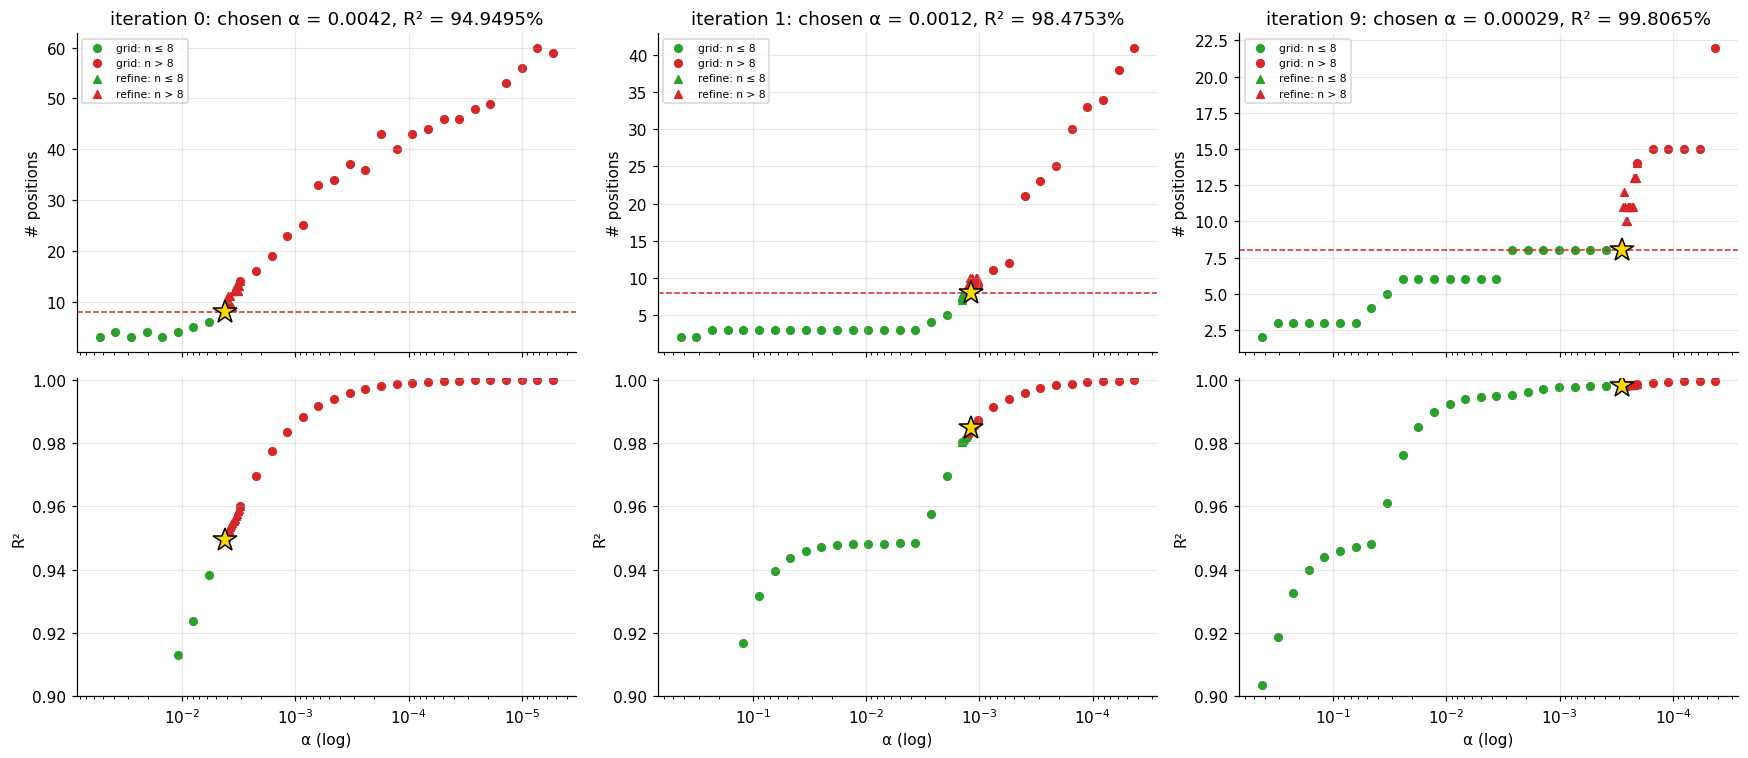

In [11]:
show = [0, 1, iters["r2"].idxmax()]
fig, axes = plt.subplots(2, len(show), figsize=(16, 7), sharex="col")
for col, it in enumerate(show):
    t = trace[trace.iter == it]
    for stage, mk in [("grid", "o"), ("refine", "^")]:
        s = t[t.stage == stage]
        okm, bad, inf = s.feasible & (s.n <= max_n), s.feasible & (s.n > max_n), ~s.feasible
        axes[0, col].scatter(s.alpha[okm], s.n[okm], c="tab:green", marker=mk, s=25, label=f"{stage}: n ≤ {max_n}")
        axes[0, col].scatter(s.alpha[bad], s.n[bad], c="tab:red", marker=mk, s=25, label=f"{stage}: n > {max_n}")
        axes[0, col].scatter(s.alpha[inf], np.zeros(inf.sum()), c="grey", marker="x", s=25, label=f"{stage}: infeasible" if inf.any() else None)
        axes[1, col].scatter(s.alpha[okm], s.r2[okm], c="tab:green", marker=mk, s=25)
        axes[1, col].scatter(s.alpha[bad], s.r2[bad], c="tab:red", marker=mk, s=25)
    r = iters.loc[it]
    axes[0, col].axhline(max_n, color="tab:red", ls="--", lw=1)
    axes[0, col].plot(r.alpha, r.n, "*", color="gold", mec="k", ms=16)
    axes[1, col].plot(r.alpha, r.r2, "*", color="gold", mec="k", ms=16)
    axes[0, col].set(xscale="log", ylabel="# positions", title=f"iteration {it}: chosen α = {r.alpha:.2g}, R² = {r.r2:.4%}")
    axes[1, col].set(xscale="log", xlabel="α (log)", ylabel="R²", ylim=(max(0.9, t.r2.min() - 0.01), 1.0005))
    axes[0, col].invert_xaxis()
    axes[0, col].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6b. How the iterations change the penalties and the selection

- **Left:** the fee multiplier `pen_j` per strike and iteration. Selected strikes become cheap (dark), the rest become expensive.
- **Middle:** the multiplier `w_j` per strike and iteration, which shows which strikes are selected and how big they are.
- **Right:** R² of each iteration's choice. The best one (≤ 8 positions) is what `lasso()` returns.

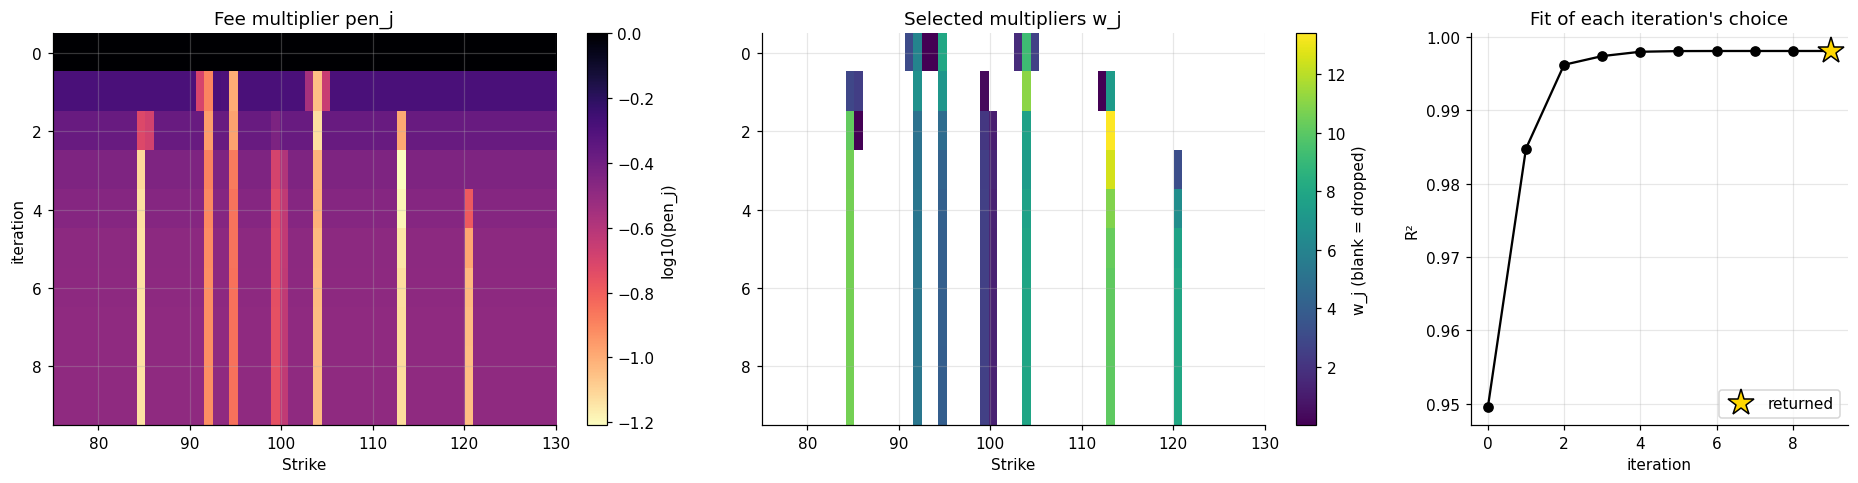

In [12]:
P = np.vstack(iters["pen"])
W = np.vstack(iters["w"])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [1, 1, 0.6]})
im0 = axes[0].imshow(np.log10(P), aspect="auto", cmap="magma_r", extent=[strikes[0], strikes[-1], len(P) - 0.5, -0.5])
plt.colorbar(im0, ax=axes[0], label="log10(pen_j)")
axes[0].set(xlabel="Strike", ylabel="iteration", title="Fee multiplier pen_j")
Wm = np.where(W > 0, W, np.nan)
im1 = axes[1].imshow(Wm, aspect="auto", cmap="viridis", extent=[strikes[0], strikes[-1], len(W) - 0.5, -0.5])
plt.colorbar(im1, ax=axes[1], label="w_j (blank = dropped)")
axes[1].set(xlabel="Strike", title="Selected multipliers w_j")
axes[2].plot(iters["iter"], iters["r2"], "o-", color="k")
bi = iters["r2"].idxmax()
axes[2].plot(bi, iters.loc[bi, "r2"], "*", color="gold", mec="k", ms=18, label="returned")
axes[2].set(xlabel="iteration", ylabel="R²", title="Fit of each iteration's choice")
axes[2].legend()
plt.tight_layout()
plt.show()

## 7. What the risk constraints do

The constraints are hard rules added to every solve:

- **floors** (ratio 1): gamma, theta, slide −5%, slide −10% must be **at least** as good as the full book
- **bid-offer** (ratio 0.8): the reduced book's unwind cost must be ≤ 80% of the full book's
- **vega band**: within ±5% of the full book

They shrink the set of allowed `w`. Theta and bid-offer are **negative** numbers, so "reduced ≥ full" means the ratio reduced / full is **≤ 1** for them (less decay, lower cost). Below, the same algorithm runs **without** them, and we compare the fit (R²) with each risk as a ratio of the full book.

R2 unconstrained = 99.8799%   constrained = 99.8065%


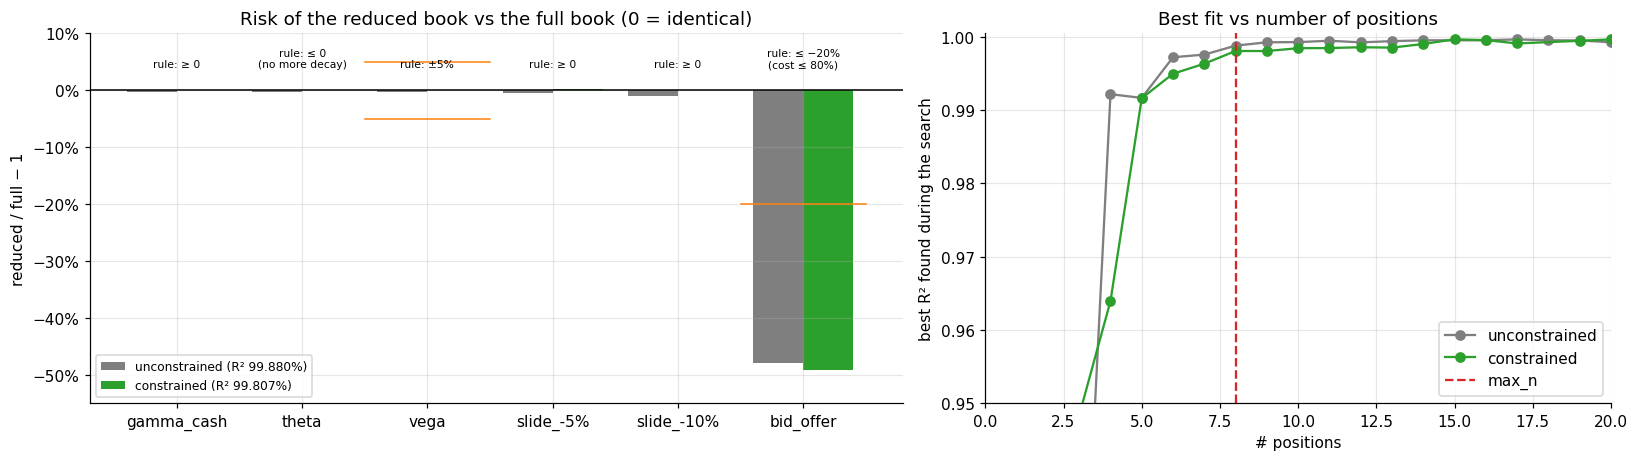

In [13]:
best_free, trace_free, iters_free = lasso_traced(X, y, risk, max_n, floors, risk_tolerance, constrained=False)
full = risk.sum()


def ratios(w):
    return (risk.T @ w) / full


comp = pd.DataFrame({"unconstrained": ratios(best_free["w"]), "constrained": ratios(best["w"])}) - 1
print(f"R2 unconstrained = {best_free['r2']:.4%}   constrained = {best['r2']:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.3), gridspec_kw={"width_ratios": [1.3, 1]})
xs = np.arange(len(comp))
axes[0].bar(xs - 0.2, comp["unconstrained"], 0.4, color="tab:grey", label=f"unconstrained (R² {best_free['r2']:.3%})")
axes[0].bar(xs + 0.2, comp["constrained"], 0.4, color="tab:green", label=f"constrained (R² {best['r2']:.3%})")
axes[0].axhline(0, color="k", lw=1)
for i, m in enumerate(comp.index):
    rule = {"bid_offer": "rule: ≤ −20%\n(cost ≤ 80%)", "vega": "rule: ±5%", "theta": "rule: ≤ 0\n(no more decay)"}.get(m, "rule: ≥ 0")
    axes[0].text(i, 0.04, rule, ha="center", fontsize=7)
axes[0].plot([1.5, 2.5], [0.05, 0.05], color="tab:orange", lw=1)
axes[0].plot([1.5, 2.5], [-0.05, -0.05], color="tab:orange", lw=1)
axes[0].plot([4.5, 5.5], [-0.2, -0.2], color="tab:orange", lw=1)
axes[0].set_xticks(xs, comp.index)
axes[0].set(ylabel="reduced / full − 1", title="Risk of the reduced book vs the full book (0 = identical)", ylim=(-0.55, 0.1))
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
axes[0].legend(fontsize=8, loc="lower left")

for lbl, tr, c in [("unconstrained", trace_free, "tab:grey"), ("constrained", trace, "tab:green")]:
    t = tr[tr.feasible].groupby("n")["r2"].max()
    axes[1].plot(t.index, t.values, "o-", color=c, label=lbl)
axes[1].axvline(max_n, color="tab:red", ls="--", label="max_n")
axes[1].set(xlabel="# positions", ylabel="best R² found during the search", title="Best fit vs number of positions", ylim=(0.95, 1.0005), xlim=(0, 20))
axes[1].legend()
plt.tight_layout()
plt.show()

Without constraints the payoff fit is slightly better, but the **down-slides come out about 1% short of the full book**, which breaks the "≥ full" floor. With constraints, gamma, theta, vega and slide −10% sit **exactly on 0** (the constraint is binding): the optimizer gives up just enough payoff fit (≈ 0.07% of R²) to meet them. Bid-offer is not binding here, because concentrating on fewer strikes already halves the unwind cost.

## 8. Final result

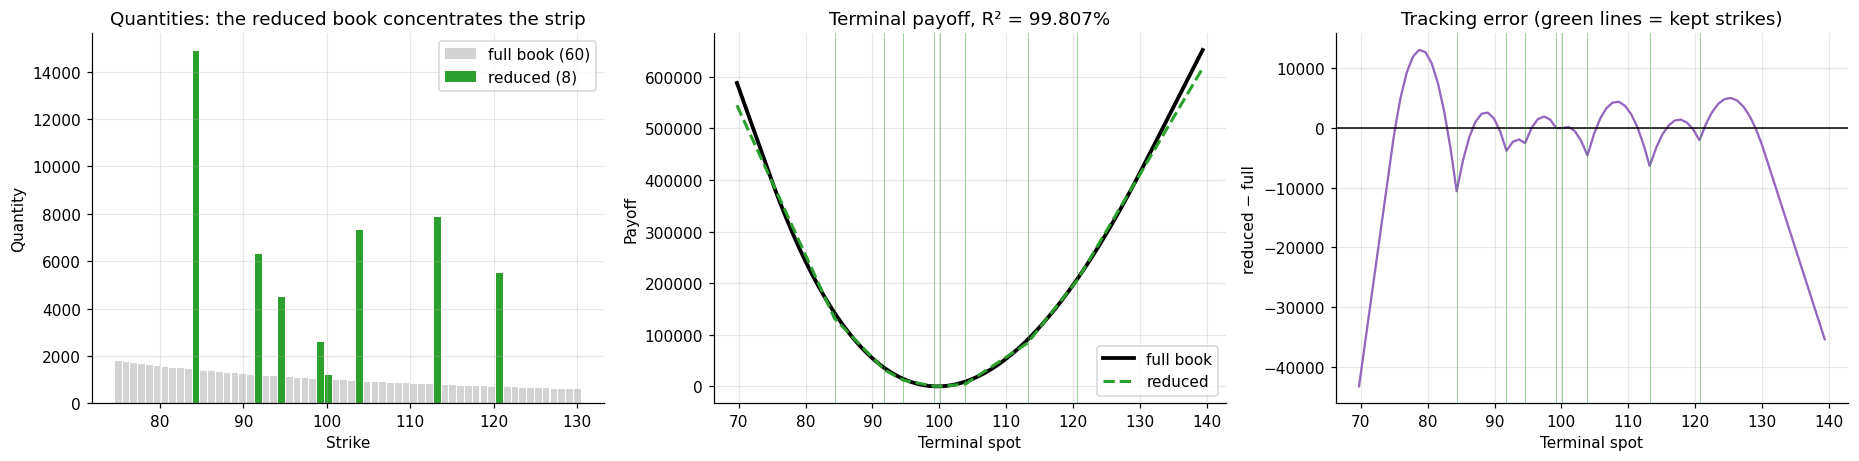

,quantity,multiplier
put_84.3,14_888,10.59
put_91.8,6_309,5.314
put_94.6,4_505,4.029
put_99.2,2_582,2.543
call_100.2,1_211,1.215
call_103.9,7_320,7.902
call_113.2,7_879,10.1
call_120.7,5_488,7.992


In [14]:
w_best = best["w"]
reduced = (portfolio_weight * w_best)[w_best > 0]
pay_full = option_terminal_payoff.loc[grid_s, names] @ portfolio_weight
pay_red = option_terminal_payoff.loc[grid_s, reduced.index] @ reduced

fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
axes[0].bar(strikes, portfolio_weight, width=0.8, color="lightgrey", label="full book (60)")
axes[0].bar(strikes[w_best > 0], reduced, width=0.8, color="tab:green", label=f"reduced ({len(reduced)})")
axes[0].set(xlabel="Strike", ylabel="Quantity", title="Quantities: the reduced book concentrates the strip")
axes[0].legend()
axes[1].plot(grid_s, pay_full, "k", lw=2.5, label="full book")
axes[1].plot(grid_s, pay_red, "--", color="tab:green", lw=2, label="reduced")
for k in strikes[w_best > 0]:
    axes[1].axvline(k, color="tab:green", lw=0.6, alpha=0.5)
axes[1].set(xlabel="Terminal spot", ylabel="Payoff", title=f"Terminal payoff, R² = {best['r2']:.3%}")
axes[1].legend()
axes[2].plot(grid_s, pay_red - pay_full, color="tab:purple")
axes[2].axhline(0, color="k", lw=1)
for k in strikes[w_best > 0]:
    axes[2].axvline(k, color="tab:green", lw=0.6, alpha=0.5)
axes[2].set(xlabel="Terminal spot", ylabel="reduced − full", title="Tracking error (green lines = kept strikes)")
plt.tight_layout()
plt.show()

display(reduced.to_frame("quantity").assign(multiplier=w_best[w_best > 0]))

### Summary of the optimization

1. **Set-up:** multipliers `w ≥ 0`, one per option, with full book = all ones. QR compresses 5,000 scenarios into 60 equations.
2. **One solve:** tracking error + `α · Σ pen_j w_j`, subject to the risk constraints. The L1 fee gives exact zeros.
3. **α search:** 30 values of α on a log scale from `top`, keep the best R² with ≤ `max_n` positions, then refine with 15 more α values before the next option would enter.
4. **Reweighting:** `pen_j = 1 / (w_j + 0.5·mean)`. Kept options become cheap and dropped ones expensive, which removes the shrinkage and sharpens the selection.
5. **Repeat** 10 times and return the best R² with ≤ `max_n` positions.